In [53]:
# 標準函式庫
import sys
import os
import warnings
import cv2


# 第三方函式庫 (科學計算/優化)
import emcee
import numpy as np
import scipy.constants as spc
from scipy.interpolate import interp1d
from scipy.optimize import fsolve # 假設你需要 fsolve

# 天文學/數據處理函式庫
from astropy import units as u
from astropy.io import fits 
from astropy.wcs import WCS
from spectral_cube import SpectralCube

# 繪圖函式庫
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import corner
from matplotlib.colors import PowerNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# 專案本地模組
import PSSpy as pss

In [54]:
Local_Standard_Velocity = 5.86 #km/s (Gupta_2024)
pa_deg = 170 + 90
pa_rad = pa_deg * np.pi / 180

In [55]:
ra_start = '19:01:06.961'
ra_end = '19:01:10.248'
dec_deg = 36 + 57/60 + 20/3600  # +31.21.38.180 => 31.3606 度
distance_pc = 160
n_pixels = 789

radius_in_au, radius_out_au = 1e2, 3e3

arcsec_range, AU_per_pixel = pss.calc_ra_arcsec(ra_start, ra_end, dec_deg, distance_pc, n_pixels)

print(f"RA arcsec range (rounded): {arcsec_range} arcsec")
print(f"AU per pixel: {AU_per_pixel:.2f} AU/pixel")

RA arcsec range (rounded): 39 arcsec
AU per pixel: 7.91 AU/pixel


In [56]:

cube = SpectralCube.read('S_CrA_13CO_spw25_tav_jupyter_shifted.fits')
header = fits.getheader('S_CrA_13CO_spw25_tav_jupyter_shifted.fits')

im_center = int(header['CRPIX2']), int(header['CRPIX1'])  # (z, x)
v0 = header['CRVAL3']          # reference velocity
dx = abs(header['CDELT1'])      # arcsec per pixel
dz = abs(header['CDELT2'])      # arcsec per pixel
dv = abs(header['CDELT3'])      # km/s per channel
v_lastch_vel = 14.8636
v_lastch_num = 150

# Subcube and moment calculation
velocity_range = [2.4926, 14.8636] * u.km / u.s  # Adjusted velocity range
subcube = cube.spectral_slab(velocity_range[0], velocity_range[1])
moment0 = subcube.moment(order=0).value
moment1 = subcube.moment(order=1).value
rms_channel = 0.026211100061251217
rms_mom0 = 5.134089023394e-2
cube_shape = subcube.shape  # (n_channels, n_z, n_x)

# mom0_3rms = np.ma.masked_where(moment0 < 3.5*rms_channel, moment0)
# mom1_3rms = np.ma.masked_where(moment0 < 3.5*rms_channel, moment1)

/opt/anaconda3/lib/python3.11/site-packages/spectral_cube/_moments.py:168: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /


In [57]:
cube_shape

(150, 778, 789)

In [58]:
np.shape(new_cube_data)

(151, 778, 789)

In [59]:
im_center

(396, 396)

In [60]:
hdu_mom0 = fits.PrimaryHDU(data=moment0, header=header)
hdu_mom0.writeto('S_CrA_13CO_mom0.fits', overwrite=True)
hdu_mom1 = fits.PrimaryHDU(data=moment1.data, header=header)
hdu_mom1.header['BUNIT'] = 'km/s'
hdu_mom1.writeto('S_CrA_13CO_mom1.fits', overwrite=True)

In [61]:
find_streamcom = np.array([[396, 396], [371, 355], [340, 355], [309, 369], [279, 389], [257, 463]]) - (im_center[0], im_center[1])

In [62]:
find_r, find_theta = pss.spherical_coords(find_streamcom[:, 0], find_streamcom[:, 1])
find_streaml = interp1d(find_r, find_theta)

In [63]:
center1 = (388, 393)  # (y, x)
center2 = (369, 382)  # (y, x)

new_center = int((center1[0] + center2[0]) / 2), int((center1[1] + center2[1]) / 2) # (y, x)

ny, nx = moment0.shape
radius = 40

# 建立 2D mask 並擴展成 3D mask
mask2d = pss.circular_mask((ny, nx), new_center, radius)
mask3d = np.repeat(mask2d[np.newaxis, :, :], subcube.shape[0], axis=0)

# 套用到 cube
masked_center_cube = subcube.with_mask(mask3d)
# masked_center_cube = masked_center_cube.with_fill_value(0)

In [64]:
# cube_data = cube.filled_data[:].value  # shape = (z, y, x)
maskcent_cube_data = masked_center_cube.filled_data[:].value  # shape = (z, y, x)

init_points = [(35, new_center[0], new_center[1]), (35, 355, 371), (35, 355, 340), (35, 369, 309), (35, 389, 279), (35, 463, 257)]  # (z, y, x) coordinates of initial points
# stream_mask = pss.grow_region(cube_data, init_points, rms_channel, sigma_thresh=3.5, max_iter=1000)
maskcent_stream_mask = pss.grow_region(maskcent_cube_data, init_points, rms_channel, sigma_thresh=3.5, max_iter=1000)

In [80]:
# masked_cube_ori = cube.with_mask(stream_mask)
masked_cube = masked_center_cube.with_mask(maskcent_stream_mask)
new_cube_data = masked_cube.with_fill_value(np.nan)
new_cube_data = new_cube_data.filled_data[:].value
# masked_cube = masked_cube.with_fill_value(0)

str_moment0 = masked_cube.moment(order=0).value
str_moment1 = masked_cube.moment(order=1).value
# str_moment0_ori = masked_cube_ori.moment(order=0).value
# str_moment1_ori = masked_cube_ori.moment(order=1).value

/opt/anaconda3/lib/python3.11/site-packages/spectral_cube/_moments.py:168: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /


In [81]:
ty, tx = (im_center[0] - new_center[0], im_center[1] - new_center[1])

# Create the 2x3 translation matrix
# M = [[1, 0, tx],
#      [0, 1, ty]]
M = np.float32([[1, 0, tx], [0, 1, ty]])

# Get the image dimensions
rows, cols= str_moment0.shape

# Apply the affine transformation
shifted_str_mom0 = np.ma.masked_invalid(cv2.warpAffine(str_moment0, M, (cols, rows), borderValue=np.nan)).data
shifted_str_mom1 = np.ma.masked_invalid(cv2.warpAffine(str_moment1, M, (cols, rows), borderValue=np.nan)).data

# shifted_str_mom0_ori = np.ma.masked_invalid(cv2.warpAffine(str_moment0_ori, M, (cols, rows), borderValue=np.nan))
# shifted_str_mom1_ori = np.ma.masked_invalid(cv2.warpAffine(str_moment1_ori, M, (cols, rows), borderValue=np.nan))

In [82]:
hdu_mom0 = fits.PrimaryHDU(data=shifted_str_mom0, header=header)
hdu_mom0.writeto('S_CrA_13CO_streamer_mom0.fits', overwrite=True)
hdu_mom1 = fits.PrimaryHDU(data=shifted_str_mom1, header=header)
hdu_mom1.writeto('S_CrA_13CO_streamer_mom1.fits', overwrite=True)

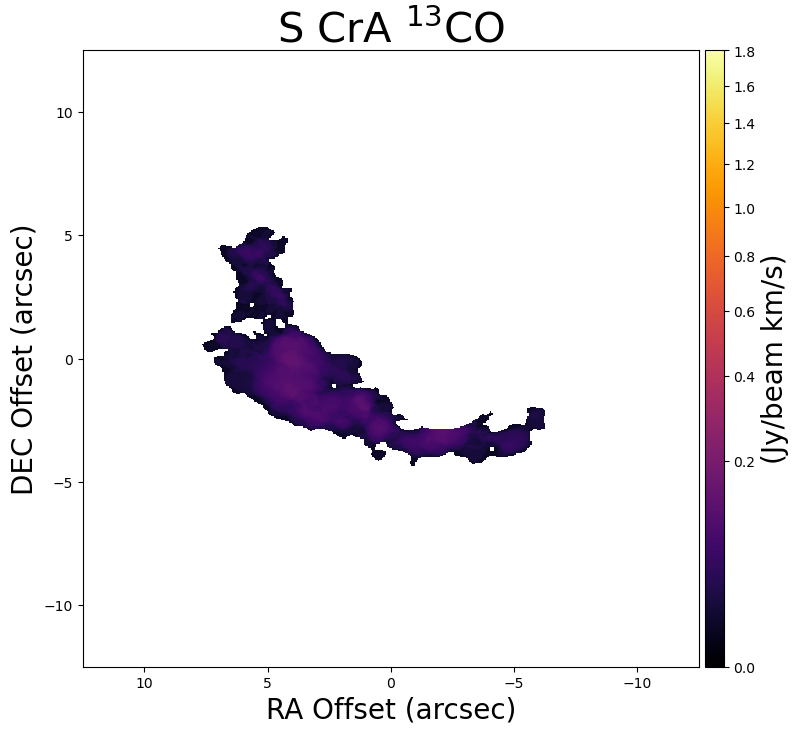

In [83]:
# 從 FITS 檔頭獲取必要的 WCS 資訊
w = WCS(header).sub(['longitude', 'latitude'])
# 獲取影像的像素維度
nx = header['NAXIS1']
ny = header['NAXIS2']

# 取得影像四個角落的物理座標（以度為單位）
bottom_left_world = w.pixel_to_world(0, 0)
top_right_world = w.pixel_to_world(nx - 1, ny - 1)

# 將度數轉換為相對角秒（以中心點為參考）
# 這裡我們假設你的 FITS 檔頭已經將參考點 (CRVAL) 設定為影像中心
# 並且你的座標是從影像中心開始計算的相對座標
# 如果不是，你需要根據你的中心點重新計算
ra_offset_arcsec = (bottom_left_world.ra.deg - header['CRVAL1']) * 3600. * np.cos(np.deg2rad(dec_deg))
dec_offset_arcsec = (bottom_left_world.dec.deg - header['CRVAL2']) * 3600.

# 設定 extent，確保它是從最小到最大
xmin = min(ra_offset_arcsec, (top_right_world.ra.deg - header['CRVAL1']) * 3600.)
xmax = max(ra_offset_arcsec, (top_right_world.ra.deg - header['CRVAL1']) * 3600.)

ymin = min(dec_offset_arcsec, (top_right_world.dec.deg - header['CRVAL2']) * 3600.)
ymax = max(dec_offset_arcsec, (top_right_world.dec.deg - header['CRVAL2']) * 3600.)

extent = (xmax, xmin, ymin, ymax)

# --- 接下來的繪圖程式碼保持不變 ---
# 繪圖
fig = plt.figure(figsize=(8.27, 8.27))
ax  = fig.add_subplot(111)
# color
norm = PowerNorm(gamma=0.5, vmin=0, vmax=1.8)
imcolor = ax.imshow(str_moment0, origin='lower', cmap='inferno', extent=extent, norm=norm)
# color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='3%', pad='1%')
cbar = fig.colorbar(imcolor, cax=cax)
cbar.set_label('(Jy/beam km/s)',fontsize=20)
ax.scatter(0, 0, c='w', s=100, marker='+')
# range
ax.set_xlim(12.5, -12.5)
ax.set_ylim(-12.5, 12.5)

# axis label
ax.set_title('S CrA '+r'$\rm ^{13}CO$',fontsize=30)
ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)
plt.show()

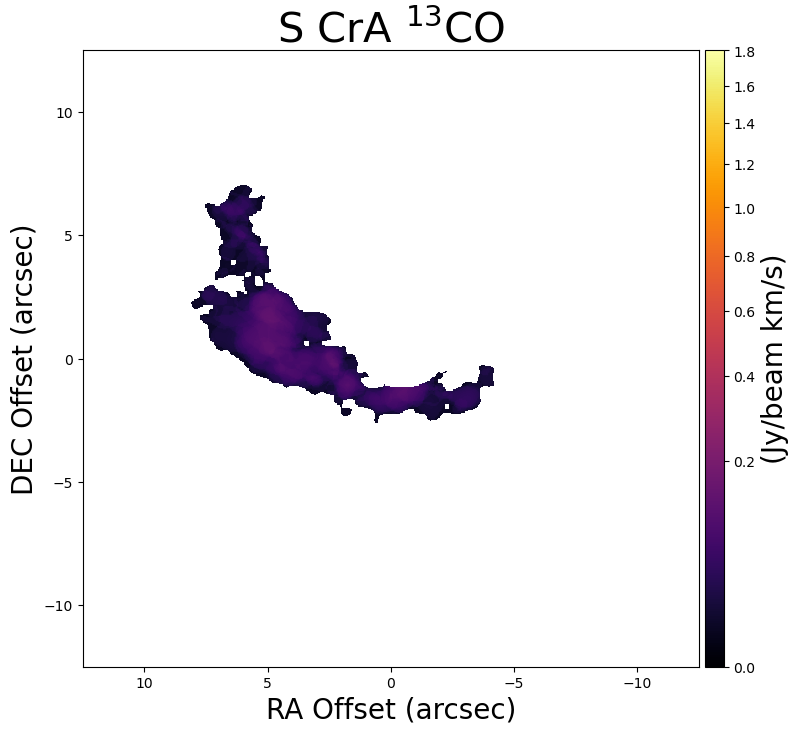

In [84]:
# ----------- input -----------
# parameters for plot
# moment I map in color
cmap       = 'inferno'  # color

# 獲取新中心點的世界坐標 (R.A._ref, Dec._ref)
ref_world = w.pixel_to_world(new_center[1], new_center[0])
ra_ref_deg = ref_world.ra.deg
dec_ref_deg = ref_world.dec.deg

# 獲取影像的像素維度
nx = header['NAXIS1']
ny = header['NAXIS2']

# 定義四個角落的像素坐標 (X 軸)
# 使用 np.array 進行向量化
x_pixels = np.array([0, nx - 1, 0, nx - 1])
y_pixels = np.array([0, 0, ny - 1, ny - 1])

# 透過 WCS 一次性轉換所有角落的坐標 (這是最關鍵的一步)
corner_worlds = w.pixel_to_world(x_pixels, y_pixels)

# 提取 R.A. 和 Dec. 的度數陣列
corner_ra_deg = corner_worlds.ra.deg
corner_dec_deg = corner_worlds.dec.deg

# 計算 R.A. 偏移 (度 -> 角秒)
ra_offset_arcsec = (corner_ra_deg - ra_ref_deg) * 3600. * np.cos(np.deg2rad(dec_deg))

# 計算 Dec 偏移 (度 -> 角秒)
dec_offset_arcsec = (corner_dec_deg - dec_ref_deg) * 3600.

# extent 格式為 (xmin, xmax, ymin, ymax)
# x 軸 (R.A.)
xmin_arcsec = np.min(ra_offset_arcsec)
xmax_arcsec = np.max(ra_offset_arcsec)

# y 軸 (Dec)
ymin_arcsec = np.min(dec_offset_arcsec)
ymax_arcsec = np.max(dec_offset_arcsec)

# 最終的 extent
extent = (xmax_arcsec, xmin_arcsec, ymin_arcsec, ymax_arcsec)

# plot, relative coordinate
# figure
fig = plt.figure(figsize=(8.27, 8.27))
ax  = fig.add_subplot(111)
# color
norm = PowerNorm(gamma=0.5, vmin=0, vmax=1.8)  # Adjust gamma for better visibility

imcolor = ax.imshow(shifted_str_mom0, origin='lower',
    cmap=cmap, extent=extent, norm=norm)
plt.gca().set_aspect('equal') 

# color bar
divider = make_axes_locatable(ax)
cax     = divider.append_axes('right', size='3%', pad='1%')
cbar = fig.colorbar(imcolor, cax=cax)
cbar.set_label('(Jy/beam km/s)',fontsize=20)

# range
ax.set_xlim(12.5, -12.5)
ax.set_ylim(-12.5, 12.5)

# axis label
ax.set_title('S CrA '+r'$\rm ^{13}CO$',fontsize=30)
ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)

# save/show
folder_path = "image"
outname  = 'S CrA'  # outputname
# plt.savefig(os.path.join(folder_path, outname+'.png'), dpi=300, bbox_inches='tight')

plt.show()


In [100]:
# -----------------------------------------------------------------------
# 1. 建立 3D 座標網格
# -----------------------------------------------------------------------
# 這裡 v, z, x 是像素編號，與 cube_shape (v, z, x) 順序一致
v, z, x = np.indices(cube_shape)
# 相對於參考像素的座標
x_rel = x - im_center[1]
z_rel = z - im_center[0]

# 計算每個體素的球座標 (r, theta)
# r, theta 會是 3D 陣列，與 data_cube 相同維度
r, theta = pss.spherical_coords(x_rel, z_rel)

N_elements = 11
pars = np.linspace(50, 158, N_elements + 1)  # 徑向距離區間

x_means = np.zeros(N_elements)
z_means = np.zeros(N_elements)
v_means = np.zeros(N_elements)
xzstd = np.zeros(N_elements)

x_array_list = []
z_array_list = []
v_array_list = []
weights_list = []

# -----------------------------------------------------------------------
# 2. 找到每個徑向區間的 xz 平均座標
# -----------------------------------------------------------------------
for i in range(N_elements):
    r_streaml = (pars[i] + pars[i+1]) / 2
    theta0 = find_streaml(r_streaml)

    # 計算 3D 權重陣列
    weight_theta = (x_rel * np.cos(theta0) + z_rel * np.sin(theta0)) / r
    # 處理 r=0 的情況
    weight_theta[r==0] = 0
    # weight_theta[weight_theta < 0.1] = 0

    # 找出指定徑向範圍和有效數據的體素
    dinds = (r > pars[i]) & (r <= pars[i+1]) & (new_cube_data > 0)
    
    if np.sum(dinds) > 0:
        # 計算加權平均
        x_means[i] = np.average(x_rel[dinds], weights=new_cube_data[dinds] * weight_theta[dinds])
        z_means[i] = np.average(z_rel[dinds], weights=new_cube_data[dinds] * weight_theta[dinds])
        
        # 計算加權標準差
        xzstd[i] = np.sqrt(np.average((x_rel[dinds] - x_means[i]) ** 2 + (z_rel[dinds] - z_means[i]) ** 2, weights=new_cube_data[dinds] * weight_theta[dinds]))
    else:
        # 如果該區間沒有有效數據，賦予 NaN
        x_means[i] = np.nan
        z_means[i] = np.nan
        xzstd[i] = np.nan


# -----------------------------------------------------------------------
# 3. 創建內插函數，用於計算高斯權重
# -----------------------------------------------------------------------
# 篩選掉 NaN 值，確保內插函數正確
valid_means_mask = np.isfinite(x_means)
if np.sum(valid_means_mask) < 2:
    print("數據太稀疏，無法建立內插函數，請檢查數據或參數")
    # 返回一個空的陣列或直接退出
    streamercom_v_pix = np.array([])
    streamercom_z_pix = np.array([])
    streamercom_x_pix = np.array([])
else:
    r_means, theta_means = pss.spherical_coords(x_means[valid_means_mask], z_means[valid_means_mask])
    theta_r = interp1d(r_means, theta_means, fill_value=(theta_means[0], theta_means[-1]), bounds_error=False)
    std_r = interp1d(r_means, xzstd[valid_means_mask], fill_value=(xzstd[0], xzstd[-1]), bounds_error=False)

# -----------------------------------------------------------------------
# 4. 計算 v, z, x 的加權平均
# -----------------------------------------------------------------------
for i in range(N_elements):
    r_ref = (pars[i] + pars[i+1]) / 2
    
    # 如果徑向區間無效，直接跳過
    if not np.isfinite(x_means[i]):
        x_means[i] = np.nan
        z_means[i] = np.nan
        v_means[i] = np.nan
        continue
        
    theta_ref = theta_r(r_ref)
    std_ref = std_r(r_ref) / r_ref
    
    # 計算 3D 高斯權重
    delta_theta = np.pi - np.abs(np.pi - np.abs(theta - theta_ref))
    weights = new_cube_data * pss.gaussian(delta_theta, 0, std_ref)
    
    dinds = (r > pars[i]) & (r <= pars[i+1]) & (new_cube_data > 0)

    # 存儲每次迴圈的值
    x_array_list.append(x_rel[dinds])
    z_array_list.append(z_rel[dinds])
    v_array_list.append(v[dinds])
    
    # 計算加權平均
    x_means[i] = np.average(x_rel[dinds], weights=weights[dinds])  
    z_means[i] = np.average(z_rel[dinds], weights=weights[dinds])
    v_means[i] = np.average(v[dinds], weights=weights[dinds])

# 5. 準備擬合所需的數據
streamercom_v_pix = np.array(v_means) 
streamercom_z_pix = np.array(z_means)
streamercom_x_pix = np.array(x_means)

x_rotated = streamercom_x_pix * np.cos(pa_rad) + streamercom_z_pix * np.sin(pa_rad)
z_rotated = -streamercom_x_pix * np.sin(pa_rad) + streamercom_z_pix * np.cos(pa_rad)

# 轉換為物理單位
streamercom_x_AU = x_rotated * AU_per_pixel
streamercom_z_AU = z_rotated * AU_per_pixel
streamercom_v_km = v_lastch_vel + (v_lastch_num - streamercom_v_pix) * dv
streamercom_v_LS_km = streamercom_v_km + Local_Standard_Velocity

print(f"從 3D 立方體中提取了 {np.sum(np.isfinite(x_means))} 個有效質心點。")

/var/folders/9m/kvnj0x452kx_fptbkd6sbbxm0000gn/T/ipykernel_10094/1464552182.py:35: RuntimeWarning: invalid value encountered in divide
  weight_theta = (x_rel * np.cos(theta0) + z_rel * np.sin(theta0)) / r


從 3D 立方體中提取了 11 個有效質心點。


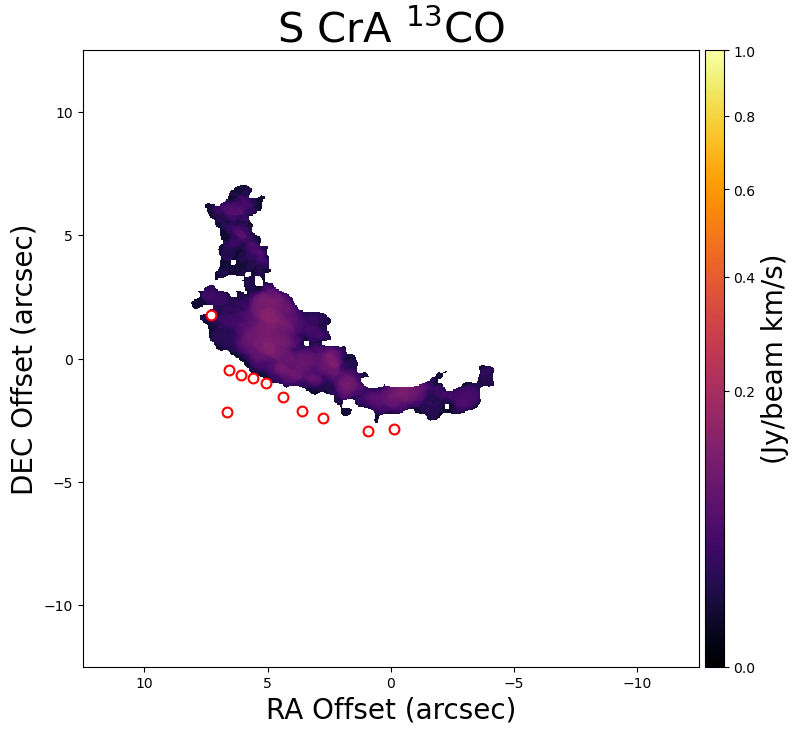

In [103]:
# -------------------------------------------------------------------------
# 1. 將 streamercom 點轉換為相對角秒
# -------------------------------------------------------------------------
# 從像素座標轉為 WCS 物件
streamercom_world = w.pixel_to_world(streamercom_x_pix + new_center[1], streamercom_z_pix + new_center[0])

# 計算相對中心的 RA 和 DEC 偏移
streamercom_ra_arcsec = (streamercom_world.ra.deg - ra_ref_deg) * 3600. * np.cos(np.deg2rad(dec_deg))
streamercom_dec_arcsec = (streamercom_world.dec.deg - dec_ref_deg) * 3600.


# plot, relative coordinate
# figure
fig = plt.figure(figsize=(8.27, 8.27))
ax  = fig.add_subplot(111)
# color
norm = PowerNorm(gamma=0.5, vmin=0, vmax=1)  # Adjust gamma for better visibility

imcolor = ax.imshow(shifted_str_mom0, origin='lower',
    cmap=cmap, extent=extent, norm=norm)
plt.gca().set_aspect('equal') 

# color bar
divider = make_axes_locatable(ax)
cax     = divider.append_axes('right', size='3%', pad='1%')
cbar = fig.colorbar(imcolor, cax=cax)
cbar.set_label('(Jy/beam km/s)',fontsize=20)

ax.scatter(0, 0, c='w', s=100, marker='+')
ax.scatter(streamercom_ra_arcsec, streamercom_dec_arcsec,
           c='white', s=50, marker='o', edgecolors='red', linewidths=1.5,
           label='Streamer Centroids')# range

# range
ax.set_xlim(12.5, -12.5)
ax.set_ylim(-12.5, 12.5)

# axis label
ax.set_title('S CrA '+r'$\rm ^{13}CO$',fontsize=30)
ax.set_xlabel('RA Offset (arcsec)',fontsize=20)
ax.set_ylabel('DEC Offset (arcsec)',fontsize=20)

# save/show
folder_path = "image"
outname  = 'S CrA'  # outputname
# plt.savefig(os.path.join(folder_path, outname+'.png'), dpi=300, bbox_inches='tight')

plt.show()
